In [23]:
import torch, torch.nn as nn, torchvision
from torchvision import models, transforms
from torchvision.models import vgg16, VGG16_Weights
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [24]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# I. Defining function

In [25]:
def get_image(path, img_transform, size = (300,300)):
    image = Image.open(path)
    image = image.resize(size, Image.LANCZOS)
    image = img_transform(image).unsqueeze(0)
    return image

In [26]:
def get_gram(m):
    """
        m: [1,C,H,W]
    """
    _, c, h, w = m.size()
    m = m.view(c, h*w)
    m = torch.mm(m, m.t())
    return m

In [27]:
def denormalize_img(inp):
    inp = inp.numpy().transpose((1, 2, 0))  # [C,H,W] -> [H,W,C]

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = inp * std + mean
    inp = np.clip(inp, 0, 1)
    return inp

# II. Define Neural Style Transfer Algorithm

## 1. Extractor

In [28]:
class FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.selected_layers = [3, 8, 15, 22]
        self.vgg = vgg16(weights=VGG16_Weights.DEFAULT).features

    def forward(self, x):
        layers_feats = []
        for layer_num, layer in self.vgg._modules.items():
            x = layer(x)
            if int(layer_num) in self.selected_layers:
                layers_feats.append(x)

        return layers_feats

## 2. Operation on pretrained VGG16 model

In [29]:
vgg16(weights=VGG16_Weights.DEFAULT)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [30]:
vgg16(weights=VGG16_Weights.DEFAULT).features._modules.items()

dict_items([('0', Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))), ('1', ReLU(inplace=True)), ('2', Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))), ('3', ReLU(inplace=True)), ('4', MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)), ('5', Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))), ('6', ReLU(inplace=True)), ('7', Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))), ('8', ReLU(inplace=True)), ('9', MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)), ('10', Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))), ('11', ReLU(inplace=True)), ('12', Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))), ('13', ReLU(inplace=True)), ('14', Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))), ('15', ReLU(inplace=True)), ('16', MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)), ('17', Conv2d(256

## 3. Training

In [31]:
img_transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean = (0.485, 0.456, 0.406), std = (0.229, 0.224, 0.225))])

In [32]:
content_img = get_image('/content/content.jpg', img_transform).to(device)
style_img = get_image('/content/style.jpg', img_transform).to(device)
generated_img = content_img.clone()
generated_img.requires_grad = True
generated_img = generated_img.to(device)

In [33]:
optimizer = torch.optim.Adam([generated_img], lr = 0.003, betas = [0.5, 0.99])

encoder = FeatureExtractor().to(device)
for p in encoder.parameters(): p.requires_grad = False

In [34]:
content_weight = 1
style_weight = 100

for epoch in range(500):
    content_features, style_features, generated_features = encoder(content_img), encoder(style_img), encoder(generated_img)

    # Calculate loss
    content_loss = torch.mean((content_features[-1] - generated_features[-1])**2)

    style_loss = 0
    for gf, sf in zip(generated_features, style_features):
        _, c,h,w = gf.size()
        gram_gf, gram_sf = get_gram(gf), get_gram(sf)
        style_loss += torch.mean((gram_gf - gram_sf)**2)/ (c*h*w)

    loss = content_weight * content_loss + style_weight * style_loss
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print("Epoch [{}]\tContent Loss: {:4f}\tStyle Loss: {:.4f}".format(epoch, content_loss, style_loss))

Epoch [0]	Content Loss: 0.000000	Style Loss: 2144.0063
Epoch [10]	Content Loss: 0.482590	Style Loss: 1674.2144
Epoch [20]	Content Loss: 1.078551	Style Loss: 1310.4648
Epoch [30]	Content Loss: 1.541786	Style Loss: 1062.5831
Epoch [40]	Content Loss: 1.901087	Style Loss: 892.4111
Epoch [50]	Content Loss: 2.174698	Style Loss: 766.6367
Epoch [60]	Content Loss: 2.386783	Style Loss: 667.0186
Epoch [70]	Content Loss: 2.559154	Style Loss: 584.4609
Epoch [80]	Content Loss: 2.702420	Style Loss: 514.3513
Epoch [90]	Content Loss: 2.824213	Style Loss: 453.9961
Epoch [100]	Content Loss: 2.928261	Style Loss: 401.5743
Epoch [110]	Content Loss: 3.017640	Style Loss: 355.7613
Epoch [120]	Content Loss: 3.095017	Style Loss: 315.6483
Epoch [130]	Content Loss: 3.164129	Style Loss: 280.4983
Epoch [140]	Content Loss: 3.226837	Style Loss: 249.6927
Epoch [150]	Content Loss: 3.284597	Style Loss: 222.6884
Epoch [160]	Content Loss: 3.337488	Style Loss: 199.0431
Epoch [170]	Content Loss: 3.385420	Style Loss: 178.3420

# III. Final image

## 1. Content image

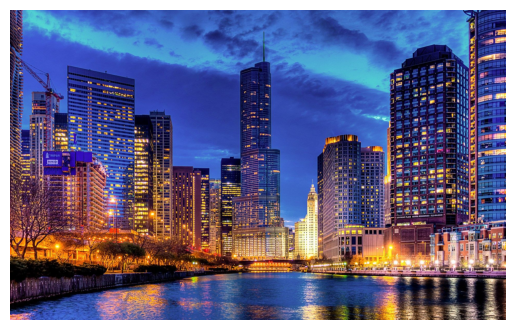

In [35]:
img = Image.open("/content/content.jpg")
img_np = np.array(img)
plt.imshow(img_np)
plt.axis('off')
plt.show()

## 2. Style image

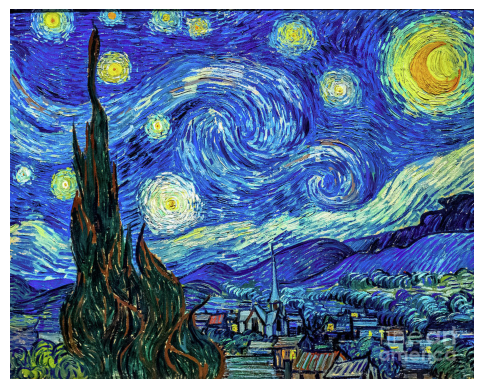

In [36]:
img = Image.open("/content/style.jpg")
img_np = np.array(img)
plt.imshow(img_np)
plt.axis('off')
plt.show()

## 3. Generated image

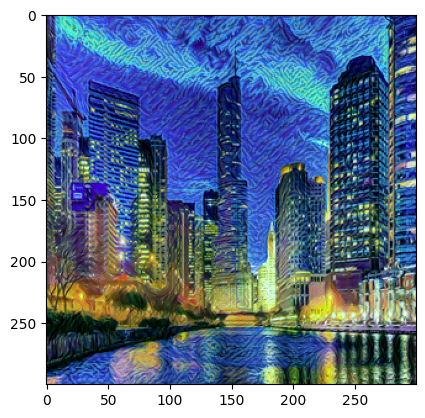

In [41]:
inp = generated_img.detach().cpu().squeeze()
inp = denormalize_img(inp)
plt.imshow(inp)